In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('smart_home_energy_consumption_large.csv')
df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2.0
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5.0
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3.0
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1.0
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5.0


In [5]:
df['timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df[['Date', 'Time', 'timestamp']].head()


,Date,Time,timestamp
0,2023-12-02,21:12,2023-12-02 21:12:00
1,2023-08-06,20:11,2023-08-06 20:11:00
2,2023-11-21,06:39,2023-11-21 06:39:00
3,2023-01-21,21:56,2023-01-21 21:56:00
4,2023-08-26,04:31,2023-08-26 04:31:00


In [6]:
df = df.sort_values('timestamp')
df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size,timestamp
8690,469,Fridge,0.30,00:24,2023-01-01,-1.2,Winter,3.0,2023-01-01 00:24:00
6244,473,TV,1.46,01:03,2023-01-01,36.3,Winter,5.0,2023-01-01 01:03:00
3208,54,TV,1.91,01:36,2023-01-01,32.7,Winter,1.0,2023-01-01 01:36:00
5763,355,Lights,0.36,01:46,2023-01-01,28.8,Winter,1.0,2023-01-01 01:46:00
17885,475,Air Conditioning,3.24,01:46,2023-01-01,13.0,Winter,5.0,2023-01-01 01:46:00


In [7]:
df.set_index('timestamp', inplace=True)
df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
timestamp,,,,,,,,
2023-01-01 00:24:00,469,Fridge,0.30,00:24,2023-01-01,-1.2,Winter,3.0
2023-01-01 01:03:00,473,TV,1.46,01:03,2023-01-01,36.3,Winter,5.0
2023-01-01 01:36:00,54,TV,1.91,01:36,2023-01-01,32.7,Winter,1.0
2023-01-01 01:46:00,355,Lights,0.36,01:46,2023-01-01,28.8,Winter,1.0
2023-01-01 01:46:00,475,Air Conditioning,3.24,01:46,2023-01-01,13.0,Winter,5.0


In [8]:
daily_energy = df.resample('D')['Energy Consumption (kWh)'].sum()
daily_energy.head()


,Energy Consumption (kWh)
timestamp,
2023-01-01,87.02
2023-01-02,62.73
2023-01-03,80.41
2023-01-04,99.92
2023-01-05,94.07


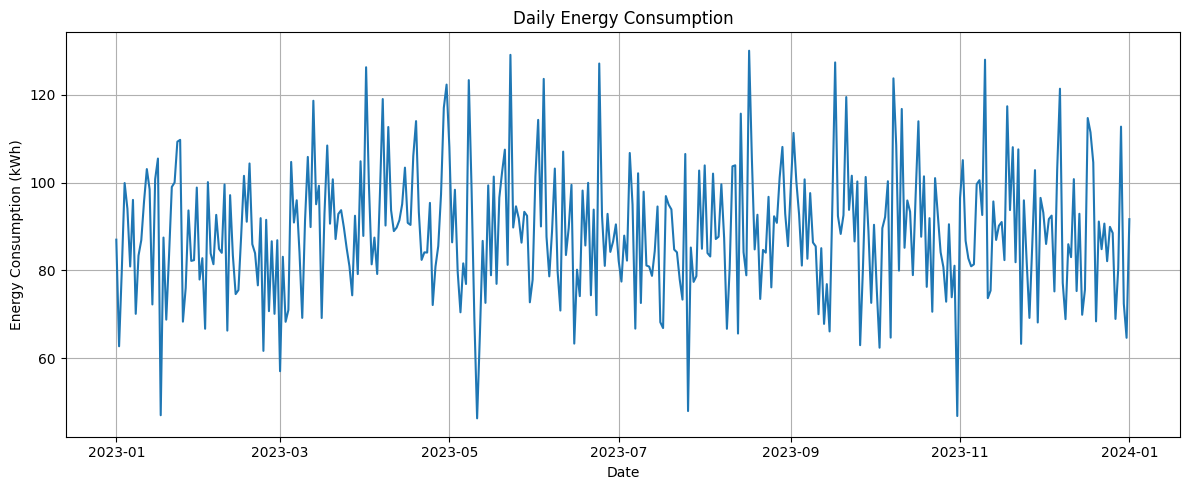

In [9]:
plt.figure(figsize=(12,5))
plt.plot(daily_energy.index, daily_energy.values)
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.title('Daily Energy Consumption')
plt.grid(True)
plt.tight_layout()
plt.show()
